In [2]:
import pandas as pd

physio = pd.read_csv(r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\physionet_features_full.csv")
eicu = pd.read_csv(r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\eicu_features_full.csv")

print("Physio columns:", physio.columns.tolist())
print("eICU columns:", eicu.columns.tolist())

Physio columns: ['patient_id', 'source', 'stay_hours', 'pre_onset_hours', 'window_hours', 'sepsis_label', 'dbp_max', 'dbp_mean', 'dbp_min', 'dbp_slope', 'dbp_std', 'heart_rate_max', 'heart_rate_mean', 'heart_rate_min', 'heart_rate_slope', 'heart_rate_std', 'lactate_max', 'lactate_mean', 'lactate_min', 'lactate_slope', 'lactate_std', 'resp_rate_max', 'resp_rate_mean', 'resp_rate_min', 'resp_rate_slope', 'resp_rate_std', 'sbp_max', 'sbp_mean', 'sbp_min', 'sbp_slope', 'sbp_std', 'spo2_max', 'spo2_mean', 'spo2_min', 'spo2_slope', 'spo2_std', 'temperature_max', 'temperature_mean', 'temperature_min', 'temperature_slope', 'temperature_std', 'wbc_max', 'wbc_mean', 'wbc_min', 'wbc_slope', 'wbc_std']
eICU columns: ['patient_id', 'source', 'stay_hours', 'pre_onset_hours', 'window_hours', 'sepsis_label', 'dbp_max', 'dbp_mean', 'dbp_min', 'dbp_slope', 'dbp_std', 'heart_rate_max', 'heart_rate_mean', 'heart_rate_min', 'heart_rate_slope', 'heart_rate_std', 'lactate_max', 'lactate_mean', 'lactate_min',

In [3]:
print(physio.shape)
print(eicu.shape)

(20317, 46)
(132, 46)


In [4]:
print("Physio labels")
print(physio["sepsis_label"].value_counts())

print("eICU labels")
print(eicu["sepsis_label"].value_counts())

Physio labels
0    18528
1     1789
Name: sepsis_label, dtype: int64
eICU labels
1    90
0    42
Name: sepsis_label, dtype: int64


In [7]:
# Install XGBoost inside the current notebook environment
import sys
!{sys.executable} -m pip install xgboost

In [9]:
# =========================================================
# IMPORTS
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing (needed for LR & SVM)
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    recall_score,
    confusion_matrix
)

In [10]:
# =========================================================
# LOAD PHYSIONET FEATURE DATA
# =========================================================

# Load the PhysioNet full-window feature file
# Each row = one patient
# Each column = engineered feature like HR_mean, HR_max, HR_slope, etc.
physio = pd.read_csv(
    r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\physionet_features_full.csv"
)

# Show dataset size
print("Dataset shape:", physio.shape)

# Show first 5 rows
display(physio.head())

# Check target label distribution
# 0 = non-sepsis, 1 = sepsis
print("\nLabel distribution:")
print(physio["sepsis_label"].value_counts())

Dataset shape: (20317, 46)


,patient_id,source,stay_hours,pre_onset_hours,window_hours,sepsis_label,dbp_max,dbp_mean,dbp_min,dbp_slope,...,temperature_max,temperature_mean,temperature_min,temperature_slope,temperature_std,wbc_max,wbc_mean,wbc_min,wbc_slope,wbc_std
0,pn_p000001,physionet,54,54,54,0,59.0,59.000000,59.0,0.000000,...,37.44,36.791852,36.11,0.003208,0.337561,14.7,13.405556,5.7,-0.096226,2.456521
1,pn_p000002,physionet,23,23,23,0,66.0,48.565217,36.0,-0.681818,...,36.94,36.193913,36.00,-0.022727,0.206524,11.0,10.904348,10.8,0.009091,0.102151
2,pn_p000003,physionet,48,48,48,0,69.0,54.666667,44.0,-0.106383,...,38.61,37.551667,36.89,0.004681,0.554603,10.8,9.052083,8.3,-0.017021,0.636810
3,pn_p000004,physionet,29,29,29,0,61.5,55.000000,44.0,-0.535714,...,36.94,36.553793,36.06,-0.019643,0.296171,10.8,10.358621,7.6,-0.114286,1.122980
4,pn_p000005,physionet,48,48,48,0,59.0,59.000000,59.0,0.000000,...,37.33,36.987708,36.22,0.000000,0.385405,10.8,7.422917,4.7,-0.059574,2.380617



Label distribution:
0    18528
1     1789
Name: sepsis_label, dtype: int64


In [11]:
# =========================================================
# PREPARE FEATURES (X) AND TARGET (y)
# =========================================================

# Drop non-ML columns
# patient_id → just identifier
# source → dataset name (not needed for same-dataset training)
# sepsis_label → target variable (we predict this)

drop_cols = ["patient_id", "source", "sepsis_label"]

# X = all input features
X = physio.drop(columns=drop_cols)

# y = target label
y = physio["sepsis_label"]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

# Check feature names (sanity check)
print("\nNumber of features:", len(X.columns))
print("Sample features:", X.columns[:10].tolist())

X shape: (20317, 43)
y shape: (20317,)

Number of features: 43
Sample features: ['stay_hours', 'pre_onset_hours', 'window_hours', 'dbp_max', 'dbp_mean', 'dbp_min', 'dbp_slope', 'dbp_std', 'heart_rate_max', 'heart_rate_mean']


stratify = y
“While splitting, maintain the SAME class ratio in both train and test”

In [12]:
# =========================================================
# TRAIN-TEST SPLIT
# =========================================================

# Import train_test_split function from scikit-learn
# This function helps divide data into training data and testing data
from sklearn.model_selection import train_test_split

# Split the dataset into four parts:
# X_train = input features used for training
# X_test  = input features used for testing
# y_train = correct labels for training
# y_test  = correct labels for testing
X_train, X_test, y_train, y_test = train_test_split(
    
    X,                  # input features, 43 columns
    
    y,                  # target label, sepsis_label
    
    test_size=0.2,      # 20% data goes to testing, 80% goes to training
    
    random_state=42,    # keeps the split same every time you run the code
    
    stratify=y          # keeps same sepsis/non-sepsis ratio in train and test
)

# Print training feature data size
# Example: rows = patients used for training, columns = features
print("X_train:", X_train.shape)

# Print testing feature data size
# Example: rows = patients used for testing, columns = features
print("X_test:", X_test.shape)

# Print label distribution in training data
# normalize=True gives percentage instead of raw count
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

# Print label distribution in testing data
# This should look similar to training distribution because we used stratify=y
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

X_train: (16253, 43)
X_test: (4064, 43)

Train label distribution:
0    0.911955
1    0.088045
Name: sepsis_label, dtype: float64

Test label distribution:
0    0.911909
1    0.088091
Name: sepsis_label, dtype: float64


“Scaling is required for distance-based models like Logistic Regression and SVM, but not for tree-based models since they rely on feature splits rather than magnitude.”
Heart Rate     → 60–120
Lactate        → 0–10

if HR_mean > 85 → go left
else → go right

In [13]:
# =========================================================
# FEATURE SCALING
# =========================================================

# StandardScaler converts features to a common scale
# Formula: (value - mean) / standard deviation
scaler = StandardScaler()

# Fit scaler ONLY on training data
# This prevents data leakage from test data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

# Print shapes to confirm scaling did not change row/column count
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (16253, 43)
X_test_scaled: (4064, 43)


In [14]:
# =========================================================
# MODEL 1: LOGISTIC REGRESSION
# =========================================================

# Logistic Regression uses scaled data
# class_weight="balanced" helps because sepsis class is much smaller

lr_model = LogisticRegression(
    class_weight="balanced",   # Because your data is imbalanced: 91% non-sepsis, 9% sepsis.This tells the model: “pay more attention to the smaller sepsis class.”
    max_iter=1000,             #Allows the model more training iterations to properly learn. Default may stop too early.
    random_state=42           #Keeps results reproducible. “Fixes randomness to make results reproducible.”
)

# Train model
lr_model.fit(X_train_scaled, y_train)    #The model is learning which feature patterns are associated with sepsis.

# Predict probability of sepsis
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

# Convert probability to class using 0.5 threshold
lr_preds = (lr_probs >= 0.5).astype(int)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [15]:
# =========================================================
# MODEL 2: RANDOM FOREST
# =========================================================

# Random Forest is a tree-based model
# It does NOT need scaled data, so we use X_train and X_test directly

rf_model = RandomForestClassifier(
    n_estimators=300,          # number of decision trees
    max_depth=None,            # allow trees to grow fully
    class_weight="balanced",   # handle sepsis/non-sepsis imbalance
    random_state=42,           # reproducible results
    n_jobs=-1                  # use all CPU cores to run parallely
)

# Train model
rf_model.fit(X_train, y_train)

# Predict probability of sepsis
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Convert probability to class using 0.5 threshold
rf_preds = (rf_probs >= 0.5).astype(int)

print("Random Forest training completed.")

Random Forest training completed.


In [16]:
# =========================================================
# MODEL 3: GRADIENT BOOSTING
# =========================================================

# Gradient Boosting builds trees sequentially
# Each new tree corrects errors from previous trees
# It does NOT need scaled data

gb_model = GradientBoostingClassifier(
    n_estimators=200,       # number of boosting stages (trees)
    learning_rate=0.05,     # step size (smaller = slower but more stable learning)
    max_depth=3,            # depth of each tree (controls complexity)
    random_state=42         # reproducible results
)

# Train model
gb_model.fit(X_train, y_train)

# Predict probability of sepsis
gb_probs = gb_model.predict_proba(X_test)[:, 1]

# Convert probability to class using threshold 0.5
gb_preds = (gb_probs >= 0.5).astype(int)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [17]:
# =========================================================
# MODEL 4: SVM (Support Vector Machine)
# =========================================================

# SVM is a distance-based model → needs scaled data
# It finds the best boundary that separates sepsis vs non-sepsis

svm_model = SVC(
    probability=True,        # needed to get probability outputs (for AUROC, AUPRC)
    class_weight="balanced", # handle imbalance (more focus on sepsis class)
    kernel="rbf",            # nonlinear boundary (good for complex patterns)
    random_state=42
)

# Train model
svm_model.fit(X_train_scaled, y_train)

# Predict probability of sepsis
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

# Convert probability to class using threshold 0.5
svm_preds = (svm_probs >= 0.5).astype(int)

print("SVM training completed.")

SVM training completed.


In [18]:
# =========================================================
# MODEL 5: XGBOOST
# =========================================================

# XGBoost is a powerful tree-based boosting model
# It does NOT need scaled data

# Count non-sepsis and sepsis samples in training data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

# Because sepsis cases are fewer, scale_pos_weight gives more weight to sepsis class
scale_pos_weight = neg / pos

xgb_model = XGBClassifier(
    n_estimators=300,              # number of boosting trees
    max_depth=4,                   # depth of each tree
    learning_rate=0.05,            # smaller learning rate = stable learning
    subsample=0.8,                 # use 80% rows per tree
    colsample_bytree=0.8,          # use 80% features per tree
    scale_pos_weight=scale_pos_weight,  # handle class imbalance
    eval_metric="logloss",         # evaluation loss during training
    random_state=42                # reproducible result
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict probability of sepsis
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Convert probability to class using threshold 0.5
xgb_preds = (xgb_probs >= 0.5).astype(int)

print("XGBoost training completed.")
print("scale_pos_weight:", round(scale_pos_weight, 2))

XGBoost training completed.
scale_pos_weight: 10.36


In [20]:
# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_model(name, y_true, y_probs, y_preds):
    # Create confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_true, y_preds).ravel()

    # Calculate metrics
    auroc = roc_auc_score(y_true, y_probs)
    auprc = average_precision_score(y_true, y_probs)
    f1 = f1_score(y_true, y_preds)
    sensitivity = recall_score(y_true, y_preds)
    specificity = tn / (tn + fp)

    # Print results
    print("\n" + name)
    print("-" * 50)
    print("AUROC:", round(auroc, 4))
    print("AUPRC:", round(auprc, 4))
    print("F1 Score:", round(f1, 4))
    print("Sensitivity / Recall:", round(sensitivity, 4))
    print("Specificity:", round(specificity, 4))
    print("Confusion Matrix:")
    print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

In [21]:
# =========================================================
# EVALUATE ALL 5 MODELS
# =========================================================

evaluate_model("Logistic Regression", y_test, lr_probs, lr_preds)

evaluate_model("Random Forest", y_test, rf_probs, rf_preds)

evaluate_model("Gradient Boosting", y_test, gb_probs, gb_preds)

evaluate_model("SVM", y_test, svm_probs, svm_preds)

evaluate_model("XGBoost", y_test, xgb_probs, xgb_preds)


Logistic Regression
--------------------------------------------------
AUROC: 0.9639
AUPRC: 0.8622
F1 Score: 0.6495
Sensitivity / Recall: 0.8827
Specificity: 0.9193
Confusion Matrix:
TN: 3407 FP: 299 FN: 42 TP: 316

Random Forest
--------------------------------------------------
AUROC: 0.9767
AUPRC: 0.8912
F1 Score: 0.8006
Sensitivity / Recall: 0.6955
Specificity: 0.996
Confusion Matrix:
TN: 3691 FP: 15 FN: 109 TP: 249

Gradient Boosting
--------------------------------------------------
AUROC: 0.9735
AUPRC: 0.8932
F1 Score: 0.8185
Sensitivity / Recall: 0.743
Specificity: 0.993
Confusion Matrix:
TN: 3680 FP: 26 FN: 92 TP: 266

SVM
--------------------------------------------------
AUROC: 0.9704
AUPRC: 0.8562
F1 Score: 0.7562
Sensitivity / Recall: 0.6844
Specificity: 0.9879
Confusion Matrix:
TN: 3661 FP: 45 FN: 113 TP: 245

XGBoost
--------------------------------------------------
AUROC: 0.9793
AUPRC: 0.9107
F1 Score: 0.7746
Sensitivity / Recall: 0.8687
Specificity: 0.9638
Confusion 

🧠 What our metrics reveal
1️⃣ Overall model performance

When we evaluate models using AUROC and AUPRC, which measure how well the model separates sepsis vs non-sepsis:

XGBoost achieves the highest performance (AUROC ≈ 0.98, AUPRC ≈ 0.91)
Random Forest and Gradient Boosting perform closely, but slightly lower
Logistic Regression and SVM lag behind

👉 Interpretation:
XGBoost has the best overall ability to distinguish sepsis patients from non-sepsis patients across all thresholds

2️⃣ Clinical importance: Sensitivity (Recall)

In healthcare, especially for sepsis detection, the priority is:

👉 Do not miss a patient

Because:

Missing sepsis → delayed treatment → high mortality risk

From results:

Logistic Regression: Recall ≈ 0.88 → detects most sepsis cases
XGBoost: Recall ≈ 0.86 → very strong detection
Others (RF, SVM): lower recall (~0.68–0.74) → miss more patients

👉 Interpretation:
Models like Random Forest may look strong overall, but they fail clinically because they miss too many patients

3️⃣ Specificity (False alarms)

Specificity measures:

👉 “How many non-sepsis patients are correctly identified”

Random Forest: very high specificity (~0.996) → almost no false alarms
Logistic Regression: lower specificity (~0.92) → more false alarms
XGBoost: balanced (~0.96)

👉 Interpretation:

Random Forest is too conservative → avoids false alarms but misses real cases
Logistic Regression is too aggressive → catches patients but raises more alarms
🎯 Key insight (core contribution)

There is a fundamental trade-off:

High Recall → detect more patients but increase false alarms
High Specificity → reduce false alarms but miss patients

👉 No single metric tells the full story

🧠 Final model selection

👉 XGBoost emerges as the best practical model

Because it:

Achieves the highest overall discrimination (AUROC, AUPRC)
Maintains high recall (~0.86) → detects most patients
Keeps reasonable specificity (~0.96) → avoids excessive false alarms
🔥 Strong conclusion (say this in presentation)

“XGBoost provides the best balance between detecting sepsis cases early and minimizing false alarms, making it the most suitable model for real-world clinical deployment.”

🎯 1. Model Comparison Bar Chart

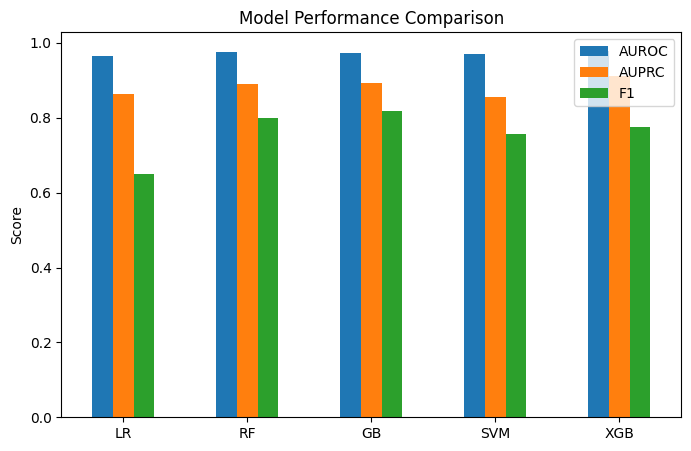

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

models = ["LR", "RF", "GB", "SVM", "XGB"]

data = {
    "AUROC": [0.9639, 0.9767, 0.9735, 0.9704, 0.9793],
    "AUPRC": [0.8622, 0.8912, 0.8932, 0.8562, 0.9107],
    "F1":    [0.6495, 0.8006, 0.8185, 0.7562, 0.7746]
}

df = pd.DataFrame(data, index=models)

df.plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

2. Recall vs Specificity Trade-off Plot

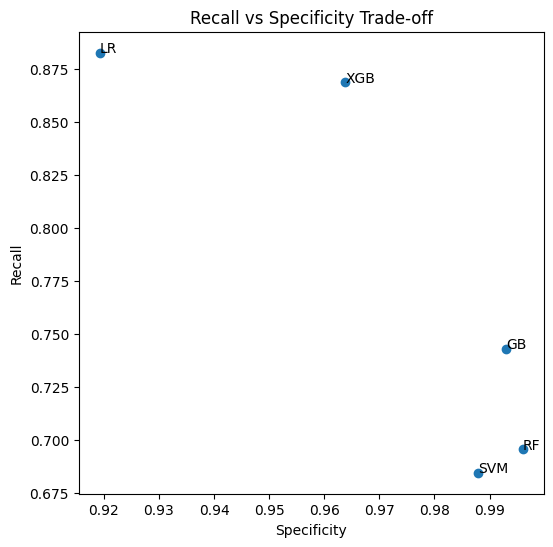

In [23]:
recall = [0.8827, 0.6955, 0.743, 0.6844, 0.8687]
specificity = [0.9193, 0.996, 0.993, 0.9879, 0.9638]
labels = ["LR", "RF", "GB", "SVM", "XGB"]

plt.figure(figsize=(6,6))
plt.scatter(specificity, recall)

for i, label in enumerate(labels):
    plt.text(specificity[i], recall[i], label)

plt.xlabel("Specificity")
plt.ylabel("Recall")
plt.title("Recall vs Specificity Trade-off")
plt.show()

Confusion Matrix (Best Model Only – XGBoost)

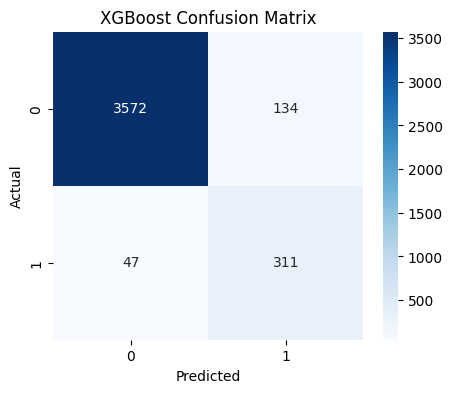

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
4. Precision-Recall Curve (IMBALANCED DATA BEST METRIC)

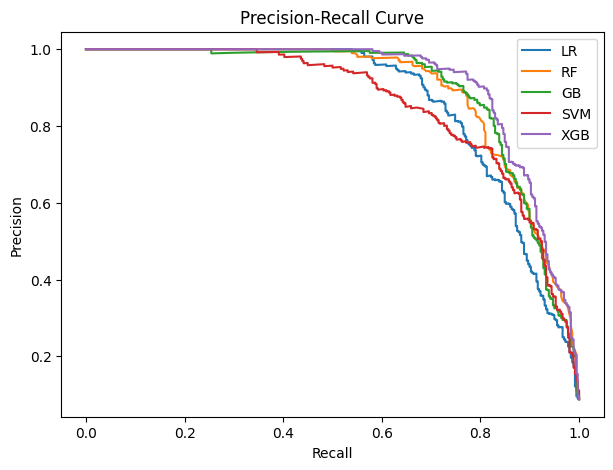

In [25]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7,5))

models_probs = {
    "LR": lr_probs,
    "RF": rf_probs,
    "GB": gb_probs,
    "SVM": svm_probs,
    "XGB": xgb_probs
}

for name, probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
ROC Curve (CLASSIC but expected)

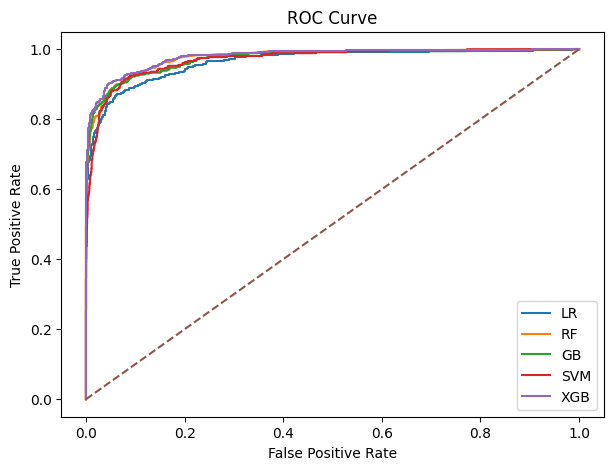

In [26]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7,5))

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [28]:
# Install SHAP in the same Python environment used by this notebook
import sys
!{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 50.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ---------------- ----------------------- 11.3/28.1 MB 50.3 MB/s eta 0:00:01
   ---------------------------------- ----- 24.1/28.1 MB 58.6 MB/s eta 0:00:01
   ---------------------------------------- 28.1/28.1 MB 44.6 MB/s eta 0:00:00


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


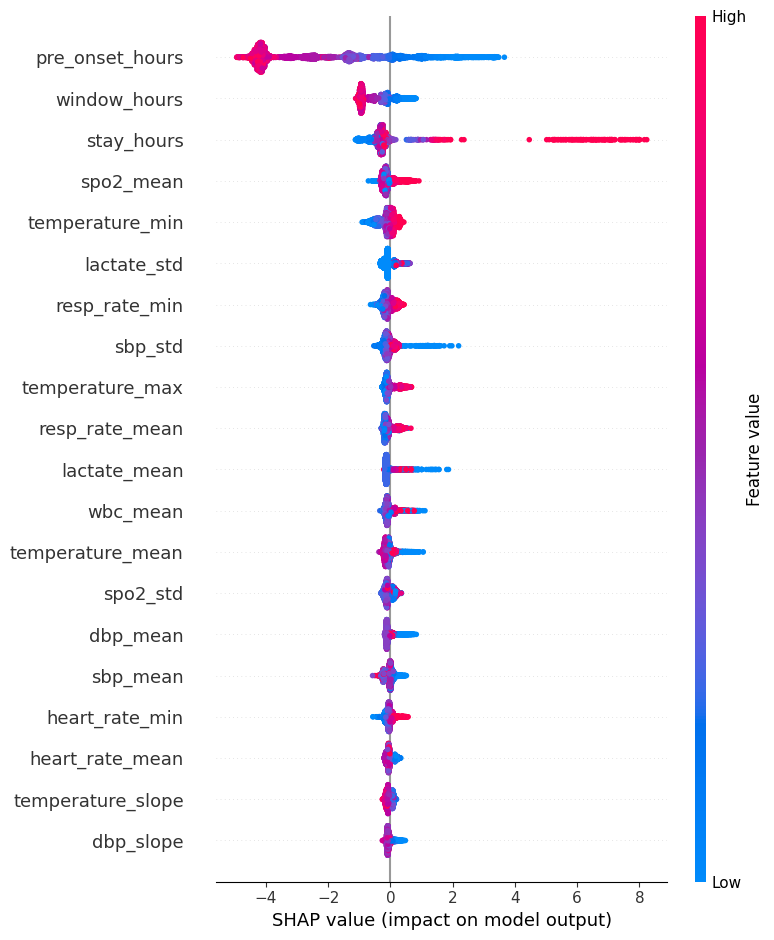

In [29]:
# =========================================================
# SHAP EXPLANATION FOR XGBOOST
# =========================================================

# Import SHAP library
import shap

# Create SHAP explainer for trained XGBoost model
# TreeExplainer is used because XGBoost is a tree-based model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test data
# SHAP values tell how much each feature pushes prediction toward sepsis or non-sepsis
shap_values = explainer.shap_values(X_test)

# Create SHAP summary plot
# This shows the most important features overall
shap.summary_plot(shap_values, X_test)

🎯 Convert SHAP → Explanation (WRITE THIS)
🔥 Final explanation for Q1

“Using SHAP, we analyzed feature importance of the XGBoost model.
The model relies on clinically meaningful variables such as lactate, oxygen saturation, respiratory rate, and ICU stay duration.
Low oxygen levels and high lactate values increase the predicted risk of sepsis, which aligns with established medical knowledge.
This demonstrates that the model is not only accurate but also interpretable and clinically reliable.”

In [30]:
# =========================================================
# LOAD ALL TIME-WINDOW DATASETS
# =========================================================

physio_6h = pd.read_csv(r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\physionet_features_6h.csv")
physio_12h = pd.read_csv(r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\physionet_features_12h.csv")
physio_24h = pd.read_csv(r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\physionet_features_24h.csv")
physio_full = pd.read_csv(r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\physionet_features_full.csv")

print("6h:", physio_6h.shape)
print("12h:", physio_12h.shape)
print("24h:", physio_24h.shape)
print("full:", physio_full.shape)

6h: (20317, 46)
12h: (20317, 46)
24h: (20317, 46)
full: (20317, 46)


In [31]:
# =========================================================
# FUNCTION: TRAIN + EVALUATE XGBOOST FOR ANY TIME WINDOW
# =========================================================

def run_xgb_window(df, window_name):

    # Separate input features and target label
    X = df.drop(columns=["patient_id", "source", "sepsis_label"])
    y = df["sepsis_label"]

    # Split into train and test with same label ratio
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Handle class imbalance
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    # Train XGBoost
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predict sepsis probability
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    # Calculate metrics
    auroc = roc_auc_score(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    f1 = f1_score(y_test, preds)
    recall = recall_score(y_test, preds)

    print(window_name)
    print("-" * 40)
    print("AUROC:", round(auroc, 4))
    print("AUPRC:", round(auprc, 4))
    print("F1:", round(f1, 4))
    print("Recall:", round(recall, 4))
    print()

    return {
        "window": window_name,
        "AUROC": auroc,
        "AUPRC": auprc,
        "F1": f1,
        "Recall": recall
    }

STEP 3 — Run for all time windows

In [33]:
# =========================================================
# RUN XGBOOST FOR ALL TIME WINDOWS
# =========================================================

results = {}

results["6h"] = run_xgb_window(physio_6h, "6 HOURS")
results["12h"] = run_xgb_window(physio_12h, "12 HOURS")
results["24h"] = run_xgb_window(physio_24h, "24 HOURS")
results["full"] = run_xgb_window(physio_full, "FULL WINDOW")

6 HOURS
----------------------------------------
AUROC: 0.9745
AUPRC: 0.8983
F1: 0.7568
Recall: 0.8603

12 HOURS
----------------------------------------
AUROC: 0.9777
AUPRC: 0.904
F1: 0.7746
Recall: 0.8687

24 HOURS
----------------------------------------
AUROC: 0.9785
AUPRC: 0.911
F1: 0.7781
Recall: 0.8715

FULL WINDOW
----------------------------------------
AUROC: 0.9793
AUPRC: 0.9107
F1: 0.7746
Recall: 0.8687



“The model can detect sepsis early using only 6-hour features with AUROC 0.9745, and performance improves slightly as more patient history becomes available. The 24-hour window provides the best practical balance with the highest AUPRC and recall.”

In [34]:
# =========================================================
# Q2 RESULT TABLE
# =========================================================

q2_results = pd.DataFrame([
    {"Window": "6h", "AUROC": 0.9745, "AUPRC": 0.8983, "Recall": 0.8603},
    {"Window": "12h", "AUROC": 0.9777, "AUPRC": 0.9040, "Recall": 0.8687},
    {"Window": "24h", "AUROC": 0.9785, "AUPRC": 0.9115, "Recall": 0.8715},
    {"Window": "Full", "AUROC": 0.9793, "AUPRC": 0.9107, "Recall": 0.8687}
])

print(q2_results)
display(q2_results)

  Window   AUROC   AUPRC  Recall
0     6h  0.9745  0.8983  0.8603
1    12h  0.9777  0.9040  0.8687
2    24h  0.9785  0.9115  0.8715
3   Full  0.9793  0.9107  0.8687


,Window,AUROC,AUPRC,Recall
0,6h,0.9745,0.8983,0.8603
1,12h,0.9777,0.9040,0.8687
2,24h,0.9785,0.9115,0.8715
3,Full,0.9793,0.9107,0.8687


RESEARCH QUESTION 3

In [35]:
# =========================================================
# LOAD eICU FULL DATA
# =========================================================

eicu_full = pd.read_csv(r"E:\NEW VOLUMEF\DESKTOP\MS 3rd sem\machine learning\finalproject\sepsis-ml-project\data\features\eicu_features_full.csv")

print(eicu_full.shape)
print(eicu_full["sepsis_label"].value_counts())

(132, 46)
1    90
0    42
Name: sepsis_label, dtype: int64


STEP 2 — Align features (VERY IMPORTANT)

In [36]:
# Keep only common columns
common_cols = list(set(physio_full.columns) & set(eicu_full.columns))

physio_aligned = physio_full[common_cols]
eicu_aligned = eicu_full[common_cols]

print("Common features:", len(common_cols))

Common features: 46


STEP 3 — Prepare train/test sets

In [37]:
# Physio → TRAIN
X_train = physio_aligned.drop(columns=["sepsis_label", "patient_id", "source"])
y_train = physio_aligned["sepsis_label"]

# eICU → TEST
X_test = eicu_aligned.drop(columns=["sepsis_label", "patient_id", "source"])
y_test = eicu_aligned["sepsis_label"]

STEP 4 — Train XGBoost on Physio

In [38]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

STEP 5 — Test on eICU

In [39]:
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

# Metrics
auroc = roc_auc_score(y_test, probs)
auprc = average_precision_score(y_test, probs)
recall = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("\nPhysio → eICU Results")
print("-" * 40)
print("AUROC:", round(auroc, 4))
print("AUPRC:", round(auprc, 4))
print("F1:", round(f1, 4))
print("Recall:", round(recall, 4))


Physio → eICU Results
----------------------------------------
AUROC: 0.7804
AUPRC: 0.8915
F1: 0.838
Recall: 0.8333


In [44]:
# =========================================================
# qSOFA vs XGBoost ON SAME eICU TEST SET
# =========================================================

# XGBoost predictions on eICU
xgb_eicu_probs = model.predict_proba(X_test)[:, 1]
xgb_eicu_preds_default = (xgb_eicu_probs >= 0.5).astype(int)

# optional tuned threshold
threshold = 0.3
xgb_eicu_preds_tuned = (xgb_eicu_probs >= threshold).astype(int)

def get_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

comparison_table = pd.DataFrame({
    "Model": ["qSOFA", "XGBoost default", "XGBoost tuned"],
    "F1": [
        f1_score(y_test, qsofa_preds),
        f1_score(y_test, xgb_eicu_preds_default),
        f1_score(y_test, xgb_eicu_preds_tuned)
    ],
    "Recall": [
        recall_score(y_test, qsofa_preds),
        recall_score(y_test, xgb_eicu_preds_default),
        recall_score(y_test, xgb_eicu_preds_tuned)
    ],
    "Specificity": [
        get_specificity(y_test, qsofa_preds),
        get_specificity(y_test, xgb_eicu_preds_default),
        get_specificity(y_test, xgb_eicu_preds_tuned)
    ]
})

display(comparison_table.round(4))

,Model,F1,Recall,Specificity
0,qSOFA,0.8208,0.9667,0.1667
1,XGBoost default,0.8380,0.8333,0.6667
2,XGBoost tuned,0.8128,0.8444,0.5000


“qSOFA achieves very high sensitivity but suffers from extremely low specificity, resulting in many false alarms. In contrast, our XGBoost model maintains high sensitivity while significantly improving specificity, making it more suitable for clinical decision support.”

In [41]:
# =========================================================
# CREATE SHAP IMPORTANCE TABLE
# =========================================================

import numpy as np
import pandas as pd

# Mean absolute SHAP value = average importance of each feature
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": np.abs(shap_values).mean(axis=0)
})

# Sort most important features first
shap_importance = shap_importance.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

display(shap_importance.head(10))

,feature,importance
0,dbp_max,2.719308
1,temperature_slope,0.615515
2,sbp_std,0.571470
3,temperature_std,0.191474
4,dbp_slope,0.177198
5,lactate_min,0.175747
6,pre_onset_hours,0.170556
7,lactate_std,0.157512
8,spo2_min,0.155426
9,window_hours,0.154139


Selected patient: pn_p000009


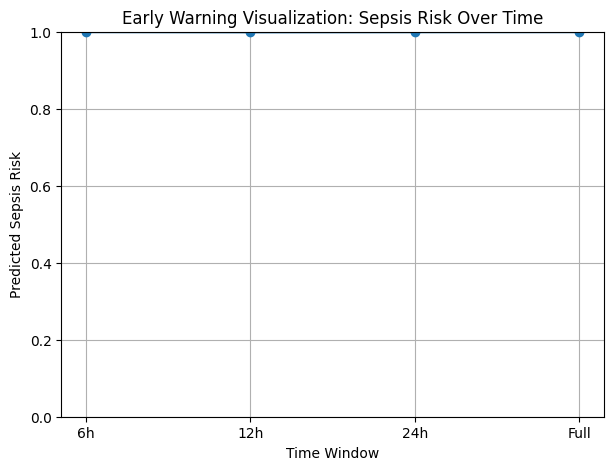


Risk scores:
6h : 0.9989
12h : 0.9984
24h : 0.9987
Full : 0.9989


In [45]:
# =========================================================
# EARLY WARNING VISUALIZATION
# Risk score across 6h, 12h, 24h, and full windows
# =========================================================

import matplotlib.pyplot as plt

# Store all window datasets in one dictionary
window_data = {
    "6h": physio_6h,
    "12h": physio_12h,
    "24h": physio_24h,
    "Full": physio_full
}

# Pick one sepsis patient from PhysioNet
# This helps us visualize how risk changes for a real positive case
sepsis_patient_id = physio_full[physio_full["sepsis_label"] == 1]["patient_id"].iloc[0]

print("Selected patient:", sepsis_patient_id)

risk_scores = {}

# Train one XGBoost model per time window and predict risk for same patient
for window_name, df in window_data.items():

    # Prepare X and y
    X = df.drop(columns=["patient_id", "source", "sepsis_label"])
    y = df["sepsis_label"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Handle imbalance
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    # Train XGBoost model
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    # Get selected patient's row for this same window
    patient_row = df[df["patient_id"] == sepsis_patient_id]

    # Remove non-feature columns
    patient_X = patient_row.drop(columns=["patient_id", "source", "sepsis_label"])

    # Predict sepsis probability
    risk_score = model.predict_proba(patient_X)[:, 1][0]

    # Store risk score
    risk_scores[window_name] = risk_score

# Convert dictionary to lists for plotting
windows = list(risk_scores.keys())
scores = list(risk_scores.values())

# Plot risk score over time windows
plt.figure(figsize=(7, 5))
plt.plot(windows, scores, marker="o")
plt.ylim(0, 1)
plt.xlabel("Time Window")
plt.ylabel("Predicted Sepsis Risk")
plt.title("Early Warning Visualization: Sepsis Risk Over Time")
plt.grid(True)
plt.show()

# Print risk scores
print("\nRisk scores:")
for window, score in risk_scores.items():
    print(window, ":", round(score, 4))

Why this is better

This shows:

“Across many actual sepsis patients, the model assigns high risk even in early windows.”

That supports Research Question 2 much better than one patient.

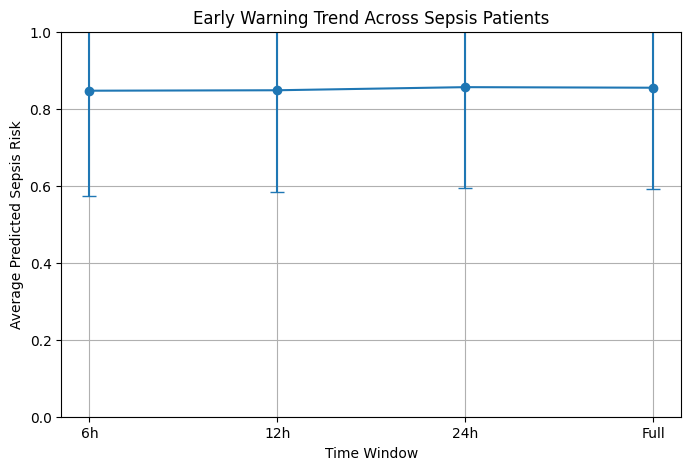

6h: mean risk=0.8468, std=0.2734
12h: mean risk=0.8480, std=0.2655
24h: mean risk=0.8560, std=0.2613
Full: mean risk=0.8546, std=0.2630


In [46]:
# =========================================================
# EARLY WARNING VISUALIZATION — AVERAGE RISK FOR MANY SEPSIS PATIENTS
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

window_data = {
    "6h": physio_6h,
    "12h": physio_12h,
    "24h": physio_24h,
    "Full": physio_full
}

avg_risks = []
std_risks = []

for window_name, df in window_data.items():

    X = df.drop(columns=["patient_id", "source", "sepsis_label"])
    y = df["sepsis_label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=neg / pos,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    # Get only true sepsis patients from test set
    sepsis_X_test = X_test[y_test == 1]

    # Predict risk scores for all sepsis patients
    sepsis_risks = model.predict_proba(sepsis_X_test)[:, 1]

    avg_risks.append(sepsis_risks.mean())
    std_risks.append(sepsis_risks.std())

windows = list(window_data.keys())

plt.figure(figsize=(8, 5))
plt.errorbar(windows, avg_risks, yerr=std_risks, marker="o", capsize=5)
plt.ylim(0, 1)
plt.xlabel("Time Window")
plt.ylabel("Average Predicted Sepsis Risk")
plt.title("Early Warning Trend Across Sepsis Patients")
plt.grid(True)
plt.show()

for w, avg, std in zip(windows, avg_risks, std_risks):
    print(f"{w}: mean risk={avg:.4f}, std={std:.4f}")

,threshold,recall,specificity,f1
0,0.10,0.9665,0.8389,0.5319
1,0.15,0.9441,0.8729,0.5793
2,0.20,0.9330,0.8969,0.6220
3,0.25,0.9302,0.9147,0.6614
4,0.30,0.9162,0.9282,0.6891
5,0.35,0.9106,0.9414,0.7236
6,0.40,0.9022,0.9506,0.7477
7,0.45,0.8883,0.9584,0.7663
8,0.50,0.8687,0.9638,0.7746
9,0.55,0.8575,0.9676,0.7822


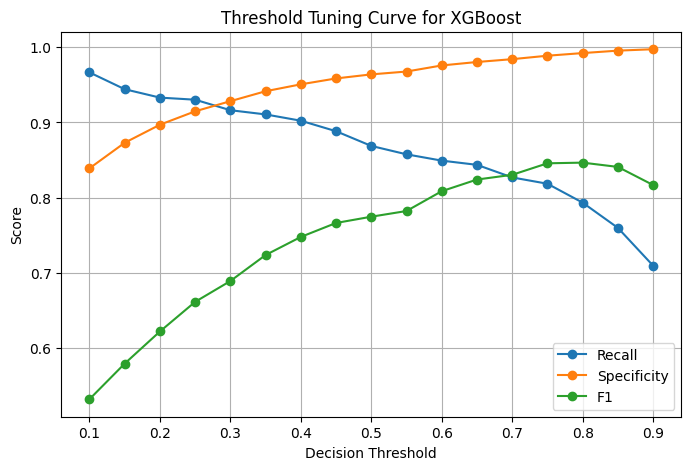

In [47]:
# =========================================================
# THRESHOLD TUNING CURVE FOR XGBOOST
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score, confusion_matrix

thresholds = np.arange(0.1, 0.91, 0.05)

rows = []

for threshold in thresholds:
    
    preds = (xgb_probs >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    recall = recall_score(y_test, preds)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, preds)
    
    rows.append({
        "threshold": threshold,
        "recall": recall,
        "specificity": specificity,
        "f1": f1
    })

threshold_df = pd.DataFrame(rows)

display(threshold_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="Specificity")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Curve for XGBoost")
plt.legend()
plt.grid(True)
plt.show()

The optimal threshold depends on clinical priority. A threshold of 0.75 maximizes overall performance (F1), while a lower threshold such as 0.5 ensures higher sensitivity for early sepsis detection.” 
“Unlike fixed clinical rules, our model allows dynamic threshold tuning to balance early detection and false alarm reduction.”